# Using our pretrained Compocyte classifiers.

In [ ]:
!sudo apt-get install -qq -o=Dpkg::Use-Pty=0 -y graphviz graphviz-dev
!pip install --quiet pygraphviz

In [ ]:
#Cytopus dependencies
!apt install libgraphviz-dev
!pip install pygraphviz

In [ ]:
!pip install --quiet git+https://github.com/WALL-E-Lab/Compocyte.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
!pip install --quiet git+https://github.com/wallet-maker/cytopus.git

In this tutorial, you will learn how to apply our pretrained Compocyte classifiers on test data.

## Preprocessing and analysis

In [ ]:
import Compocyte
from Compocyte.core.hierarchical_classifier import HierarchicalClassifier
from Compocyte.pretrained import til_pretrained, pbmc_pretrained
import scanpy as sc

# Works the same way with til_pretrained
hc = pbmc_pretrained()
adata = sc.datasets.pbmc3k()
adata.raw = adata.copy()

# Alternatively, upload data to google drive and read it
# from google.colab import drive
# drive.mount('/content/gdrive')
# adata = sc.read_h5ad('/content/gdrive/test.h5ad')


hc.load_adata(adata)
hc.predict_all_child_nodes('Blood')

Neither graph nor dict_of_cell_relations defined upon initialization.
Please run .load() to load an existing classifier.
Predicting at Blood.
Predicting at leukocyte.
Predicting at PB.
Predicting at B.
Predicting at B-memory.
Predicting at plasma-blast.
Predicting at M.
Predicting at DC.
Predicting at cDC.
Predicting at mono.
Predicting at i-mono.
Predicting at c-mono.
Predicting at nc-mono.
Predicting at TNK.
Predicting at ILC.
Predicting at NK.
Predicting at T.
Predicting at abT.
Predicting at CD4-T.
Predicting at CD8-T.
Predicting at CD8-T-effector.
Predicting at CD8-T-KLRG1pos-effector.
Predicting at TCM.


In [ ]:
hc.adata.obs

,Level_1_pred,Level_2_pred,Level_3_pred,Level_4_pred,Level_5_pred,Level_6_pred,Level_7_pred,Level_8_pred
index,,,,,,,,
AAACATACAACCAC-1,leukocyte,TNK,T,abT,CD8-T,CD8-T-effector,CD8-T-KLRG1pos-effector,CD8-T-KLRG1pos-effector_nonexhausted
AAACATTGAGCTAC-1,leukocyte,PB,B,,,,,
AAACATTGATCAGC-1,leukocyte,TNK,T,abT,CD4-T,CD4-T-naive,,
AAACCGTGCTTCCG-1,leukocyte,M,mono,c-mono,inf-c-mono,,,
AAACCGTGTATGCG-1,leukocyte,TNK,ILC,NK,CD56dim-NK,,,
...,...,...,...,...,...,...,...,...
TTTCGAACTCTCAT-1,leukocyte,M,mono,c-mono,inf-c-mono,,,
TTTCTACTGAGGCA-1,leukocyte,PB,plasma-blast,plasma-blast_proliferating,,,,
TTTCTACTTCCTCG-1,leukocyte,PB,B,B-naive,,,,


In [ ]:
hc.adata

AnnData object with n_obs × n_vars = 2700 × 5000
    obs: 'Level_1_pred', 'Level_2_pred', 'Level_3_pred', 'Level_4_pred', 'Level_5_pred', 'Level_6_pred', 'Level_7_pred', 'Level_8_pred'
    var: 'gene_ids'
    uns: 'log1p'

In [ ]:
#convert into hierarchical annotation with Cytopus

#load cytopus knowledge base
G = cp.KnowledgeBase()

#get nested dict of hierarchy in cytopus knowledge base
hierarchy_dict = cp.tl.hierarchy.get_hierarchy_dict(G)
#build hierarchy class
H = cp.tl.hierarchy.Hierarchy(hierarchy_dict)

In [ ]:
#add cells to annotation object
H.add_cells(hc.adata, obs_columns=['Level_1_pred', 'Level_2_pred', 'Level_3_pred', 'Level_4_pred', 'Level_5_pred', 'Level_6_pred', 'Level_7_pred', 'Level_8_pred'])

In [ ]:
#starting on top of the hierarchy we can find the most granular label for each cell. Here, we start from the root node 'all-cells' so that all cells will be annotated.
H.query_ancestors(query_node='all-cells', adata=hc.adata, obs_key='hierarchical_query')

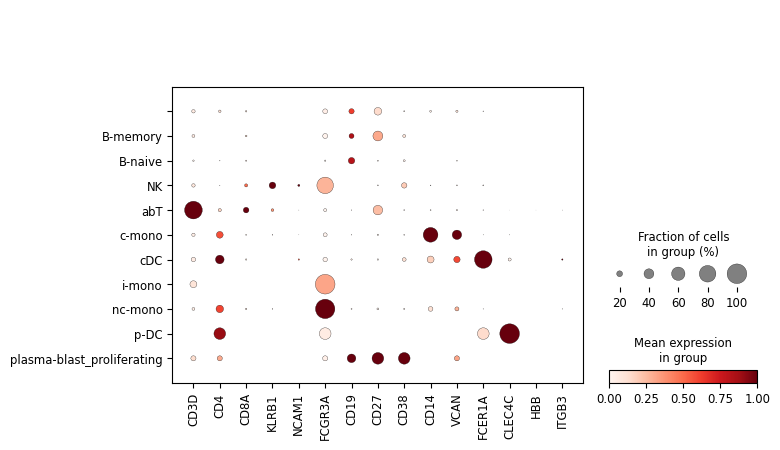

In [ ]:
sc.pl.dotplot(hc.adata, var_names=['CD3D','CD3G','TRAC','TRDC',
                                    'CD4', 'CD8A', 'KLRB1', 'NCAM1', 'FCGR3A', 'CD19', 'CD79A','IGHD','CD27','IGHG1',
                                      'CD38','SDC1', 'CD14', 'S100A8', 'LYZ',  'NRP1','IRF4','IRF7','IRF8',
                                       'CD1C','CLEC4A','XCR1', 'HBB', 'ITGB3'], standard_scale='var', use_raw=True, groupby='hierarchical_query')

While this is a very simple marker panel on an intermediate classification level, results seem reasonable.